In [5]:
pip install pandas scikit-learn

In [11]:
import pandas as pd

data = pd.read_csv(r"D:\Envi\pre_cssv.csv")

print(data.columns)

Index(['ORIG_FID', 'Id', 'class', 'NDWI', 'NDVI_Clip', 'b2_Band2', 'b3_Band2',
       'b4_Band2', 'b2_Band8'],
      dtype='object')


In [13]:
X = data[['NDWI', 'NDVI_Clip', 'b2_Band2', 'b3_Band2',
       'b4_Band2', 'b2_Band8']]
y = data['class']
X = X.fillna(X.mean())
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8333333333333334
Confusion Matrix:
 [[44 11]
 [ 9 56]]
              precision    recall  f1-score   support

           0       0.83      0.80      0.81        55
           1       0.84      0.86      0.85        65

    accuracy                           0.83       120
   macro avg       0.83      0.83      0.83       120
weighted avg       0.83      0.83      0.83       120



In [15]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf')
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("\nSVM Accuracy:", accuracy_score(y_test, y_pred_svm))


SVM Accuracy: 0.8


In [17]:
from sklearn.neural_network import MLPClassifier

ann = MLPClassifier(hidden_layer_sizes=(50,50), max_iter=500, random_state=42)
ann.fit(X_train, y_train)

y_pred_ann = ann.predict(X_test)

print("\nANN Accuracy:", accuracy_score(y_test, y_pred_ann))


ANN Accuracy: 0.8


In [19]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5)

print("\nK-Fold Scores:", scores)
print("Mean Accuracy:", scores.mean())


K-Fold Scores: [0.825      0.8625     0.85       0.8375     0.78481013]
Mean Accuracy: 0.8319620253164557


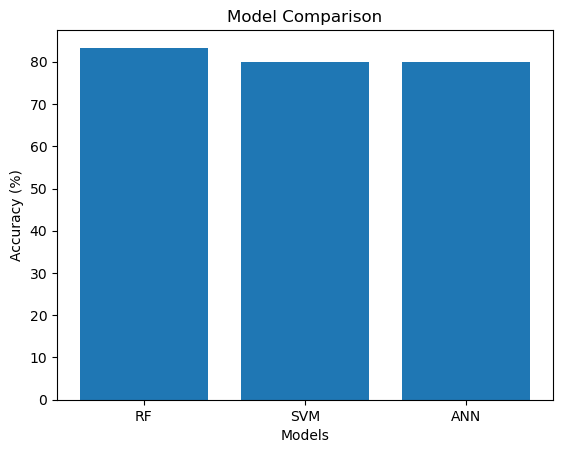

In [21]:
import matplotlib.pyplot as plt

models = ['RF', 'SVM', 'ANN']
accuracy = [83.33, 80.00, 80.00]

plt.bar(models, accuracy)
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.title("Model Comparison")
plt.show()

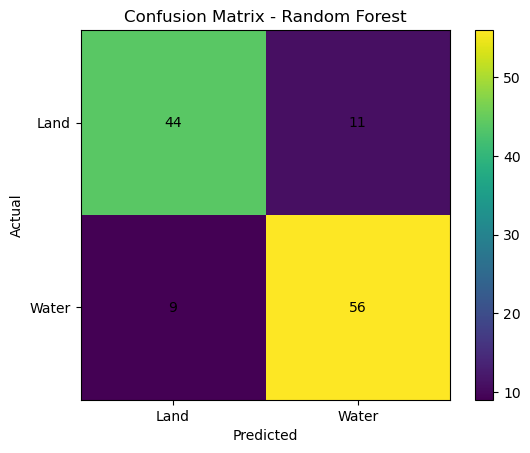

In [27]:
import matplotlib.pyplot as plt
import numpy as np

cm = np.array([[44, 11],
               [9, 56]])


plt.figure()
plt.imshow(cm)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ['Land', 'Water'])
plt.yticks([0, 1], ['Land', 'Water'])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.colorbar()
plt.show()